**Mashalov Rasulbek, OSTC2U, Machine Learning, HomeWork 7, 30th March, 2026**

In [2]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

**EXERCISE 1**

In [8]:
#loading the data
iris = load_iris()
X = iris.data
y = iris.target

#creating train/test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2021)

#scaliing the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"[INFO] Iris dataset loaded, training set size: {X_train_scaled.shape[0]}")

[INFO] Iris dataset loaded, training set size: 120


In [9]:
print("[INFO] Starting SVM Hyperparameter Search for 'C'...")

c_values = [0.01, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0] #using 0.01 because C has to be > 0

#empty list to store the results
accuracies = []

#looping thru each C value, train a model, and save the accuracy
for c in c_values:
    #initializing the SVM with the current C value
    svm_model = SVC(C=c, random_state=2021)
    svm_model.fit(X_train_scaled, y_train)

    #getting predictions and calculating accuracy
    y_pred = svm_model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    #saving
    accuracies.append(acc)
    print(f"  -> Model with C={c} trained. Accuracy: {acc * 100:.2f}%")

[INFO] Starting SVM Hyperparameter Search for 'C'...
  -> Model with C=0.01 trained. Accuracy: 20.00%
  -> Model with C=0.5 trained. Accuracy: 96.67%
  -> Model with C=1.0 trained. Accuracy: 96.67%
  -> Model with C=1.5 trained. Accuracy: 96.67%
  -> Model with C=2.0 trained. Accuracy: 96.67%
  -> Model with C=2.5 trained. Accuracy: 96.67%
  -> Model with C=3.0 trained. Accuracy: 96.67%
  -> Model with C=3.5 trained. Accuracy: 96.67%
  -> Model with C=4.0 trained. Accuracy: 96.67%
  -> Model with C=4.5 trained. Accuracy: 96.67%
  -> Model with C=5.0 trained. Accuracy: 96.67%


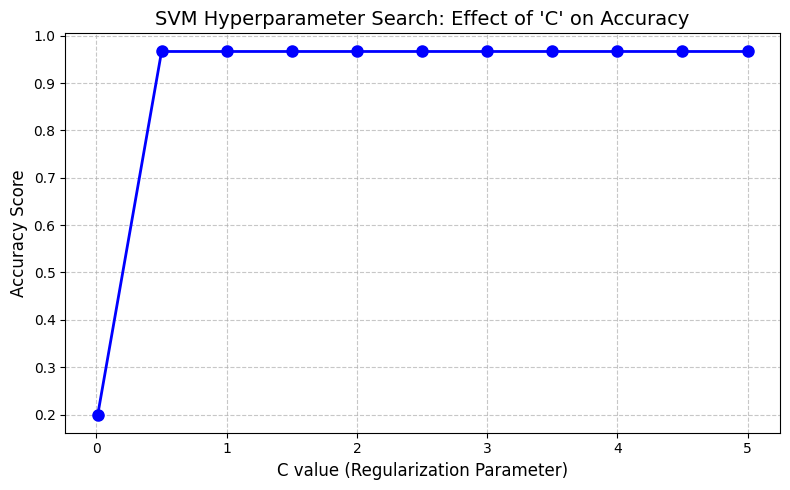

In [10]:
#seting up the canvas
plt.figure(figsize=(8, 5))

#ploting the C values against the accuracies
plt.plot(c_values, accuracies, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

# titling&labeling
plt.title("SVM Hyperparameter Search: Effect of 'C' on Accuracy", size=14)
plt.xlabel("C value (Regularization Parameter)", size=12)
plt.ylabel("Accuracy Score", size=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()